# Gaussian Mixture Model
**Gaussian Mixture Model** is a probabilistic model that assumes all data points are generated from a mixture of several Gaussian distributions with unknown parameters. Unlike hard clustering methods like K-Means that assigns each data point to one cluster based on the closest centroid which often doesn't align with the complexity of real-world data. GMMs perform soft clustering meaning each data point belongs to multiple clusters with certain probabilities. Each Gaussian in the mixture is defined by:

- **Mean (μ):** The center of the distribution.
- **Covariance (Σ):** Describes the spread and orientation.
- **Mixing coefficient (π):** Represents the proportion of each Gaussian in the mixture.
---
## Work Flow
The Gaussian mixture model assigns a probability to each data point $x_n$ of belonging to a cluster. The probability of data point ​ coming from Gaussian cluster k is expressed as
$$
P(z_n = k \mid x_n) = \frac{\pi_k \cdot \mathcal{N}(x_n \mid \mu_k, \Sigma_k)}{\sum_{j=1}^K \pi_j \cdot \mathcal{N}(x_n \mid \mu_j, \Sigma_j)}
$$

where:
- $z_n = k$ is a latent variable indicating which Gaussian the point belongs to.
- $\pi$  is the mixing probability of the k-th Gaussian.
- $\mathcal{N}(x_n \mid \mu_k, \Sigma_k)$ is the Gaussian distribution with mean $\mu_k$ and covariance $\Sigma_k$

Next we need to calculate the overall likelihood of observing a data point $x_n$ under all Gaussians. This is achieved by summing over all possible clusters (Gaussians) for each point:
$$
P(x_n) = \sum_{k=1}^K \pi_k \, \mathcal{N}(x_n \mid \mu_k, \Sigma_k)
$$

where:
- $P(x_n)$ is the overall likelihood of observing the data point $x_n$
- The sum accounts for all possible Gaussians k.

### [The Expectation-Maximization (EM) Algorithm](https://github.com/omor-niloy/CSE4212-Machine-Learning-Lab/blob/main/Assignment%206/EM.ipynb)

To fit a Gaussian Mixture Model to the data we use the Expectation-Maximization (EM) algorithm which is an iterative method that optimize the parameters of the Gaussian distributions like mean, covariance and mixing coefficients. It works in two main steps:

- **Expectation Step (E-step):** In this step the algorithm calculates the probability that each data point belongs to each cluster based on the current parameter estimates (mean, covariance, mixing coefficients).
- **Maximization Step (M-step):** After estimating the probabilities the algorithm updates the parameters (mean, covariance and mixing coefficients) to better fit the data.
##### Formula
$$
L(\mu_k, \Sigma_k, \pi_k) = \prod_{n=1}^N \sum_{k=1}^K \pi_k \, \mathcal{N}(x_n \mid \mu_k, \Sigma_k)
$$
The E-step computes the probabilities that each data point belongs to each Gaussian while the M-step updates the parameters  $\mu_k$, $\Sigma_k$​ and $\pi_k$ based on these probabilities.

---
## Advantages of GMM
- **Flexible Cluster Shapes:** Unlike K-Means which assumes spherical clusters it can model clusters with arbitrary shapes.
- **Soft Assignment:** GMM assign a probability for each data point to belong to each cluster while K-Means assigns each point to exactly one cluster.
- **Handles Overlapping Data:** GMM performs well when clusters overlap or have varying densities. Since it uses probability distributions, it can assign a point to multiple clusters with different probabilities
## Limitations of GMM
- **Computational Complexity:** GMM can take a lot of time and computer power especially when working with large datasets. because it uses a step-by-step method to keep improving its guesses about the data.
- **Choosing the Number of Clusters:** Just like other clustering methods GMM needs you to decide how many groups you want to split the data into before starting. But there are more methods like the Bayesian Information Criterion (BIC) and Akaike Information Criterion (AIC) can help in selecting the optimal number of clusters based on the data.
---
### Source: [GeeksforGeeks Gaussian Mixture Model](https://www.geeksforgeeks.org/machine-learning/gaussian-mixture-model/)
---

# Implementation of GMM 
- Dataset: We use only two features: sepal length and sepal width.
- Fitting the Model: We fit the data as a mixture of 3 Gaussians.
- Result: The model assigns each data point to a cluster based on the probabilities. After convergence GMM model will have updated the parameters to best fit the data.

In [ ]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

Text(0.5, 1.0, 'Raw Iris Data')

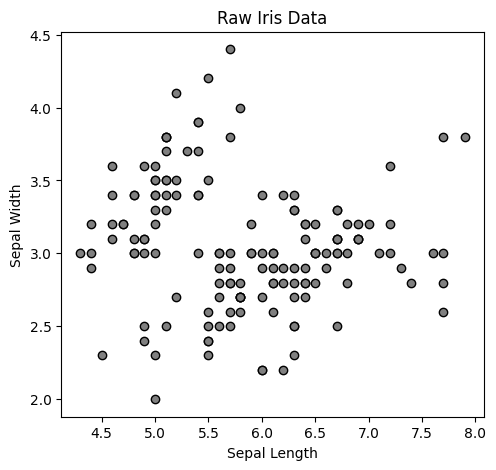

In [2]:
iris = load_iris()
X = iris.data[:, :2]  

# Plot raw data before clustering
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c='gray', edgecolor='k')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Raw Iris Data')

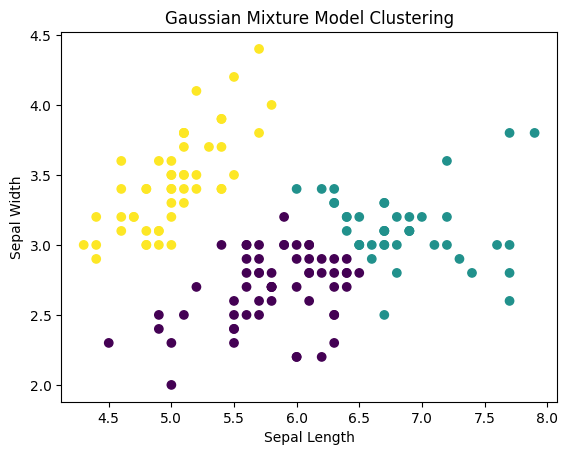

In [6]:
gmm = GaussianMixture(n_components=3)
gmm.fit(X)

labels = gmm.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Gaussian Mixture Model Clustering')
plt.show()